<a href="https://colab.research.google.com/github/Sampavi01/Hotel_Revenue_Forecasting/blob/forecasting/Catboost_optimizations/trial2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# ================== IMPORTS ==================
import os
from datetime import timedelta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

# ================== CONFIG / CONSTANTS ==================
np.random.seed(42)

INPUT_FILE_NAME = 'Model_Training_Datasets.xlsx'
TEST_SET_DAYS = 60
MAPE_EPSILON = 1e-6

TARGET_RAW_COLS = ['Revenue_By_BreakFast', 'Revenue_By_Dinner', 'Revenue_By_Lunch']
LAG_DAYS = [1, 7, 14]
ROLL_WINDOWS = [7]

OUTPUT_DIR = 'github_results'


In [39]:
 # ================== UTILITY FUNCTIONS ==================
def add_lag_and_rolling(df, target_cols, lag_days, roll_windows):
    df = df.copy()
    for col in target_cols:
        for lag in lag_days:
            df[f'{col}_lag{lag}'] = df[col].shift(lag)
        if pd.api.types.is_numeric_dtype(df[col]):
            for w in roll_windows:
                df[f'{col}_rollmean{w}'] = df[col].rolling(window=w, min_periods=1).mean().shift(1)
                df[f'{col}_rollstd{w}'] = df[col].rolling(window=w, min_periods=1).std().shift(1).fillna(0)
    return df.fillna(0)


def smape(y_true, y_pred, eps=MAPE_EPSILON):
    numer = np.abs(y_pred - y_true)
    denom = (np.abs(y_true) + np.abs(y_pred)).clip(min=eps)
    return np.mean(2.0 * numer / denom) * 100.0


# ================== PLOTTING ==================
def plot_test_results(test_df, center_name, meal_period):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    plt.figure(figsize=(12, 6))
    plt.plot(test_df['Date'], test_df['Actual_Revenue'], label='Actual Revenue', marker='o')
    plt.plot(test_df['Date'], test_df['Predicted_Revenue'], label='Predicted Revenue', marker='x')
    plt.title(f'Actual vs Predicted Revenue (Test) - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Revenue'); plt.legend()
    plt.grid(True, alpha=0.5); plt.xticks(rotation=45); plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{safe_name}_{meal_period}_actual_vs_pred.png")
    plt.show()
    plt.close()


def plot_residuals_over_time(residuals_df, center_name, meal_period):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    residuals_df = residuals_df.copy()
    residuals_df['Residual'] = residuals_df['Actual_Revenue'] - residuals_df['Predicted_Revenue']
    plt.figure(figsize=(12, 5))
    plt.plot(residuals_df['Date'], residuals_df['Residual'], marker='.', linestyle='None', alpha=0.6)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Test Residuals Over Time - {center_name} - {meal_period}')
    plt.xlabel('Date'); plt.ylabel('Residual'); plt.grid(True, alpha=0.5)
    plt.xticks(rotation=45); plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{safe_name}_{meal_period}_residuals.png")
    plt.close()


def save_training_curves_cat(center_name, meal_period, cat_evals):
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    safe_name = center_name.replace(" ", "_")

    plt.figure(figsize=(12, 6))
    if cat_evals is not None and 'learn' in cat_evals:
        if 'RMSE' in cat_evals['learn']:
            plt.plot(cat_evals['learn']['RMSE'], label='CatBoost Train RMSE', color='#1f77b4')
        if 'validation' in cat_evals and 'RMSE' in cat_evals['validation']:
            plt.plot(cat_evals['validation']['RMSE'], label='CatBoost Val RMSE', color='#ff7f0e')

    plt.title(f'Training Curves: {center_name} - {meal_period} (CatBoost)')
    plt.xlabel('Iterations'); plt.ylabel('RMSE')
    plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{safe_name}_{meal_period}_metrics.png")
    plt.close()

In [40]:
# ================== DATA LOADER ==================
def load_center_from_excel(file_path, center_sheet_name):
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

In [41]:
# ================== TRAINING: CATBOOST ONLY ==================
def train_and_plot_for_center_cat(df_center, center_name, cat_params=None):
    # --- Feature engineering ---
    df_center = add_lag_and_rolling(df_center, TARGET_RAW_COLS, LAG_DAYS, ROLL_WINDOWS)
    df_center = df_center.sort_values('Date').reset_index(drop=True)

    # --- Train/test split ---
    max_date = df_center['Date'].max()
    test_start_date = max_date - timedelta(days=TEST_SET_DAYS)
    df_train_full = df_center[df_center['Date'] < test_start_date].copy().dropna()
    df_test_full = df_center[df_center['Date'] >= test_start_date].copy()

    if df_train_full.empty or df_test_full.empty:
        print(f"Skipping center {center_name}: Training or Test set is empty.")
        return

    # --- Features ---
    feature_cols = [c for c in df_train_full.columns if c not in ['Date'] + TARGET_RAW_COLS]
    numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df_train_full[c])]
    categorical_features = [c for c in feature_cols if c not in numeric_features]

    X_train = df_train_full[feature_cols].copy()
    X_test = df_test_full[feature_cols].copy()

    cat_feature_indices = [X_train.columns.get_loc(c) for c in categorical_features]

    summary_rows = []

    # --- Default params ---
    if cat_params is None:
        cat_params = {"iterations": 300, "learning_rate": 0.005, "depth": 6,
                      "loss_function": "RMSE", "random_seed": 42, "verbose": False}

    # ================== LOOP OVER MEAL PERIODS ==================
    for raw_target_col in TARGET_RAW_COLS:
        meal_period = raw_target_col.replace("Revenue_By_", "")

        # Prepare target
        y_train = df_train_full[raw_target_col].values
        y_test = df_test_full[raw_target_col].values

        # --- Train CatBoost ---
        cat_model = CatBoostRegressor(**cat_params)
        cat_model.fit(
            X_train, y_train,
            cat_features=cat_feature_indices,
            eval_set=(X_test, y_test),
            verbose=False
        )
        y_pred_cat = cat_model.predict(X_test)
        cat_evals = cat_model.get_evals_result()

        # --- Metrics ---
        rmse_val = np.sqrt(mean_squared_error(y_test, y_pred_cat))
        mape_val = np.mean(np.abs((y_test - y_pred_cat) / (y_test + MAPE_EPSILON))) * 100.0
        smape_val = smape(y_test, y_pred_cat)

        print(f"📈 {center_name} - {meal_period}: RMSE={rmse_val:.2f}, MAPE={mape_val:.2f}%, SMAPE={smape_val:.2f}%")

        # --- Plots ---
        plot_df = pd.DataFrame({
            "Date": df_test_full["Date"],
            "Actual_Revenue": y_test,
            "Predicted_Revenue": y_pred_cat
        })
        plot_test_results(plot_df, center_name, meal_period)
        plot_residuals_over_time(plot_df, center_name, meal_period)
        save_training_curves_cat(center_name, meal_period, cat_evals)

        # --- Summary row ---
        summary_rows.append({
            "Center": center_name,
            "Meal_Period": meal_period,
            "RMSE": rmse_val,
            "MAPE": mape_val,
            "SMAPE": smape_val
        })

    # ================== SAVE SUMMARY ==================
    summary_df = pd.DataFrame


================= Revenue Centre 1 =================
📈 Revenue Centre 1 - BreakFast: RMSE=1107.25, MAPE=1143799664.54%, SMAPE=56.63%


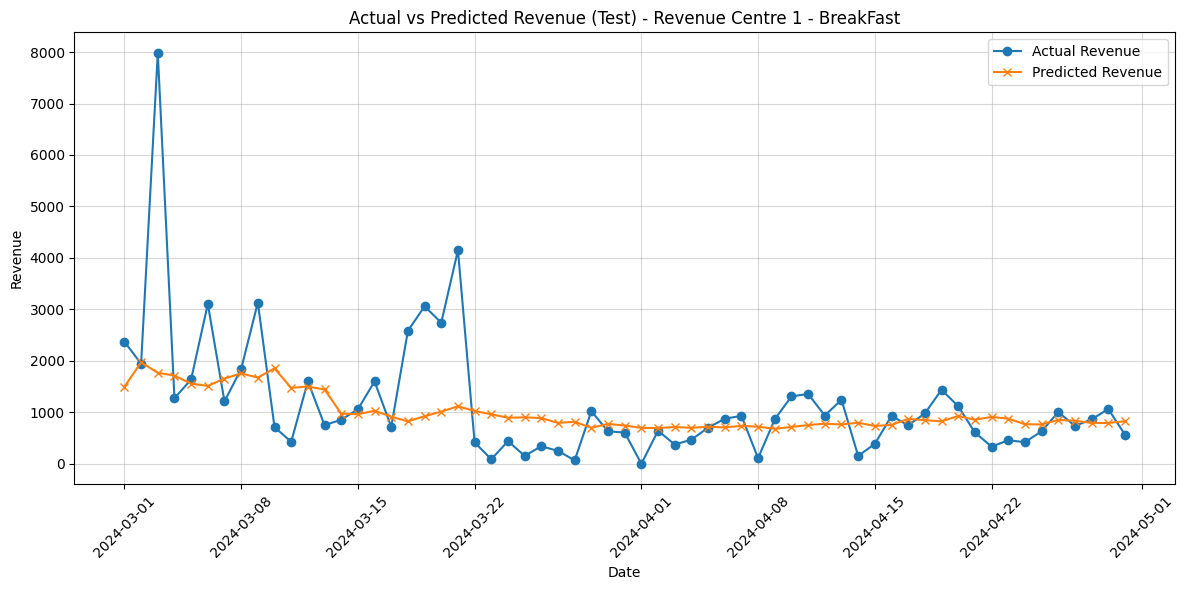

📈 Revenue Centre 1 - Dinner: RMSE=1514.39, MAPE=59.00%, SMAPE=41.21%


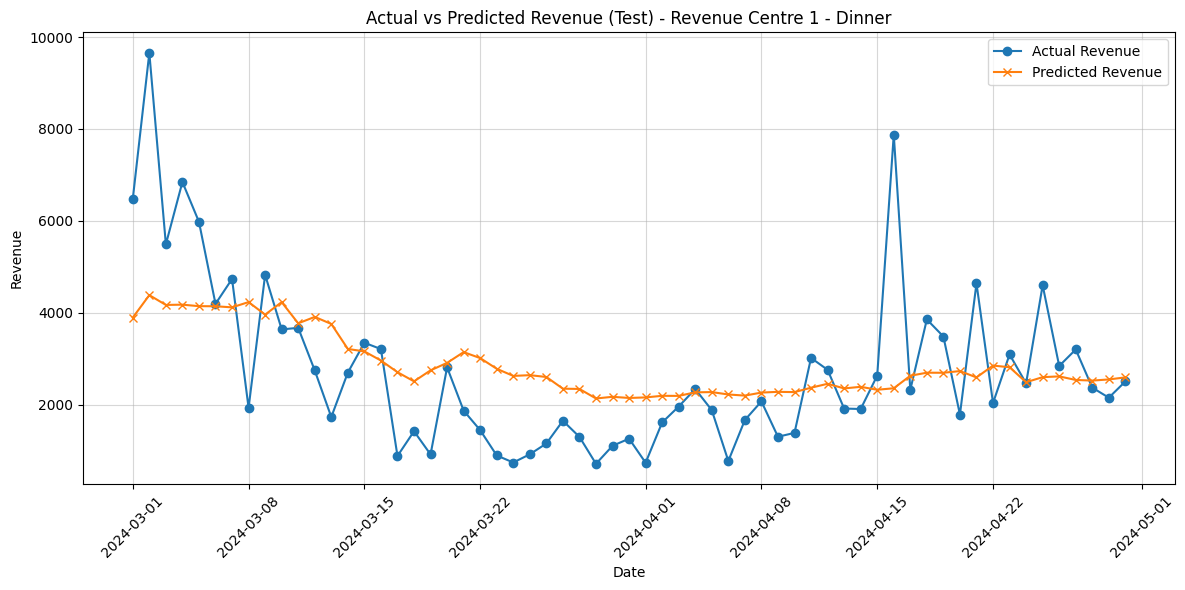

📈 Revenue Centre 1 - Lunch: RMSE=613.33, MAPE=2093640892.48%, SMAPE=65.20%


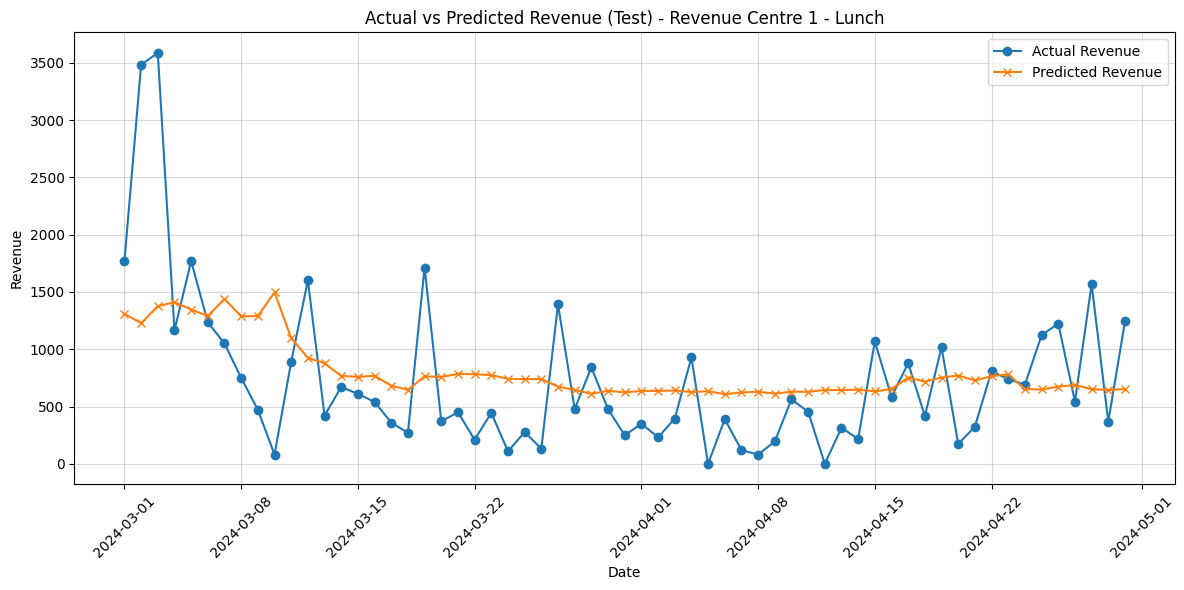

In [42]:
# ================== LOAD CENTERS AND RUN ==================
def load_center_from_excel(file_path, center_sheet_name):
    """Load one center's sheet from Excel and parse Date column."""
    df = pd.read_excel(file_path, sheet_name=center_sheet_name)
    if 'Date' in df.columns:
        df['Date'] = pd.to_datetime(df['Date'])
    else:
        raise ValueError("Expected a 'Date' column in the sheet.")
    return df

if __name__ == '__main__':
    # Iterate through centers (adjust range as needed)
    for center_id in range(0, 1):
        try:
            df_center = load_center_from_excel(INPUT_FILE_NAME, center_id)
            display_name = f"Revenue Centre {center_id+1}"
            print(f"\n================= {display_name} =================")
            train_and_plot_for_center_cat(df_center, display_name)
        except Exception as e:
            print(f"⚠️ Skipping {center_id}: {e}")

In [43]:
!zip -r plots.zip plots
from google.colab import files
files.download("plots.zip")

updating: plots/ (stored 0%)
updating: plots/Revenue_Centre_1_BreakFast_metrics.png (deflated 14%)
updating: plots/Revenue_Centre_1_Dinner_metrics.png (deflated 10%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>